# Visualizations — MVTec Bottle

This notebook produces every plot we need for the slide deck and the meeting:

1. Dataset overview & class distribution
2. Sample gallery: normal vs each defect type
3. Ground-truth masks (the "answer key")
4. Defect overlay: image + mask highlighted
5. Defect size distribution (how much of an image is defective?)
6. Effect of training-time augmentation
7. **(After training)** confusion matrix on the validation set
8. **(After training)** Grad-CAM and LIME side-by-side gallery

Every plot saves to `figures/` so you can drop them straight into the slides.
Run the cells top to bottom.

## 0. Setup

In [ ]:
# Make src/ importable from the notebook
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Create figures/ folder for saved plots
FIGURES = Path.cwd().parent / 'figures'
FIGURES.mkdir(exist_ok=True)
print(f'Figures will be saved to: {FIGURES}')

Figures will be saved to: /Users/aryanjadhav2033/Desktop/Aryan Space/Visual Analytics/Visual-Analytics/figures


In [ ]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Project imports
from config import DATA_DIR, CATEGORIES, IMAGE_SIZE, DEVICE
from dataset import MVTecDataset, build_train_transform, build_eval_transform

# Consistent plot style across the notebook
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Categories: {CATEGORIES}')
print(f'Device    : {DEVICE}')

Categories: ['bottle']
Device    : mps


## 1. Dataset overview

Quick numerical summary: how many normal vs defective images do we have, broken down by defect type?

In [ ]:
# Walk the folder tree and count images per (split, defect_type)
def count_images():
    rows = []
    for cat in CATEGORIES:
        cat_path = DATA_DIR / cat
        for split in ['train', 'test']:
            split_path = cat_path / split
            if not split_path.exists():
                continue
            for defect_dir in sorted(split_path.iterdir()):
                if not defect_dir.is_dir():
                    continue
                n = len(list(defect_dir.glob('*.png')))
                rows.append({
                    'category': cat,
                    'split': split,
                    'defect': defect_dir.name,
                    'count': n,
                })
    return rows

rows = count_images()
print(f'{"category":<10}{"split":<8}{"defect":<20}{"count":>8}')
print('-' * 48)
for r in rows:
    print(f'{r["category"]:<10}{r["split"]:<8}{r["defect"]:<20}{r["count"]:>8}')
print('-' * 48)
print(f'{"TOTAL":<38}{sum(r["count"] for r in rows):>8}')

category  split   defect                 count
------------------------------------------------
bottle    train   good                     209
bottle    test    broken_large              20
bottle    test    broken_small              22
bottle    test    contamination             21
bottle    test    good                      20
------------------------------------------------
TOTAL                                      292


### 1.1 Class distribution bar chart

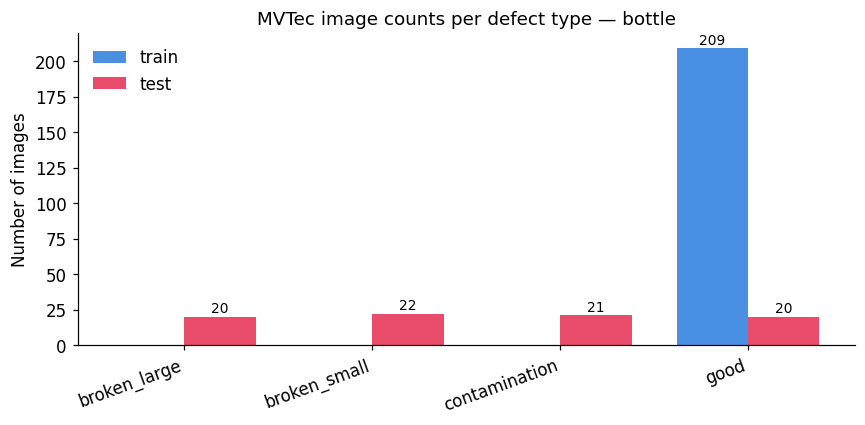

In [ ]:
# Bar chart of image counts per defect type, color-coded by split
defect_types = sorted({r['defect'] for r in rows})
splits = ['train', 'test']
colors = {'train': '#4A90E2', 'test': '#E94B6A'}

x = np.arange(len(defect_types))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4))
for i, split in enumerate(splits):
    counts = [next((r['count'] for r in rows if r['defect'] == d and r['split'] == split), 0)
              for d in defect_types]
    bars = ax.bar(x + (i - 0.5) * width, counts, width, label=split, color=colors[split])
    # Annotate each bar with its value
    for bar, c in zip(bars, counts):
        if c > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                    str(c), ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(defect_types, rotation=20, ha='right')
ax.set_ylabel('Number of images')
ax.set_title(f'MVTec image counts per defect type — {CATEGORIES[0]}')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / '01_class_distribution.png')
plt.show()

**What this tells us:** the `train/good` bar is huge (only normal images are used for training in vanilla MVTec). All the defective images sit in `test/`, which is why our `train.py` mixes half of `test/` into training — otherwise the model would never see a defect.

## 2. Sample gallery

One representative image from each defect type, plus a normal one for comparison.

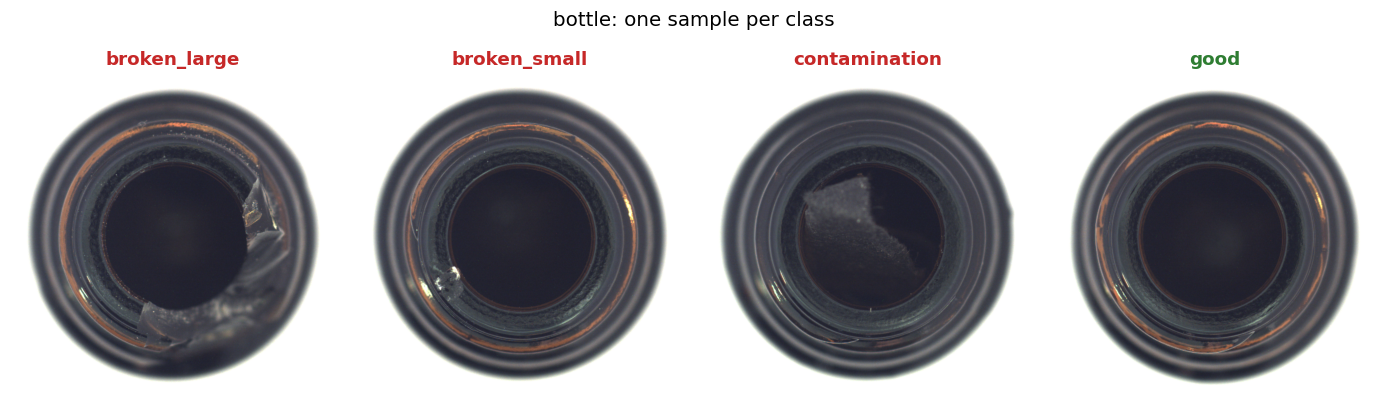

In [ ]:
cat = CATEGORIES[0]
cat_path = DATA_DIR / cat

# Get one normal + first image of each defect type
defect_dirs = sorted([d for d in (cat_path / 'test').iterdir() if d.is_dir()])

n_cols = len(defect_dirs)
fig, axes = plt.subplots(1, n_cols, figsize=(3.2 * n_cols, 3.6))
if n_cols == 1:
    axes = [axes]

for ax, ddir in zip(axes, defect_dirs):
    img_path = sorted(ddir.glob('*.png'))[0]
    img = Image.open(img_path)
    ax.imshow(img)
    title_color = '#2E7D32' if ddir.name == 'good' else '#C62828'
    ax.set_title(f'{ddir.name}', color=title_color, fontweight='bold')
    ax.axis('off')

fig.suptitle(f'{cat}: one sample per class', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / '02_sample_gallery.png')
plt.show()

## 3. Ground-truth masks (the answer key)

For every defective test image, MVTec ships a black-and-white mask marking exactly where the defect is.
This is what makes MVTec special — most datasets don't have this.

We'll use these masks later to compute **IoU**: how well does Grad-CAM/LIME's heatmap overlap with the real defect?

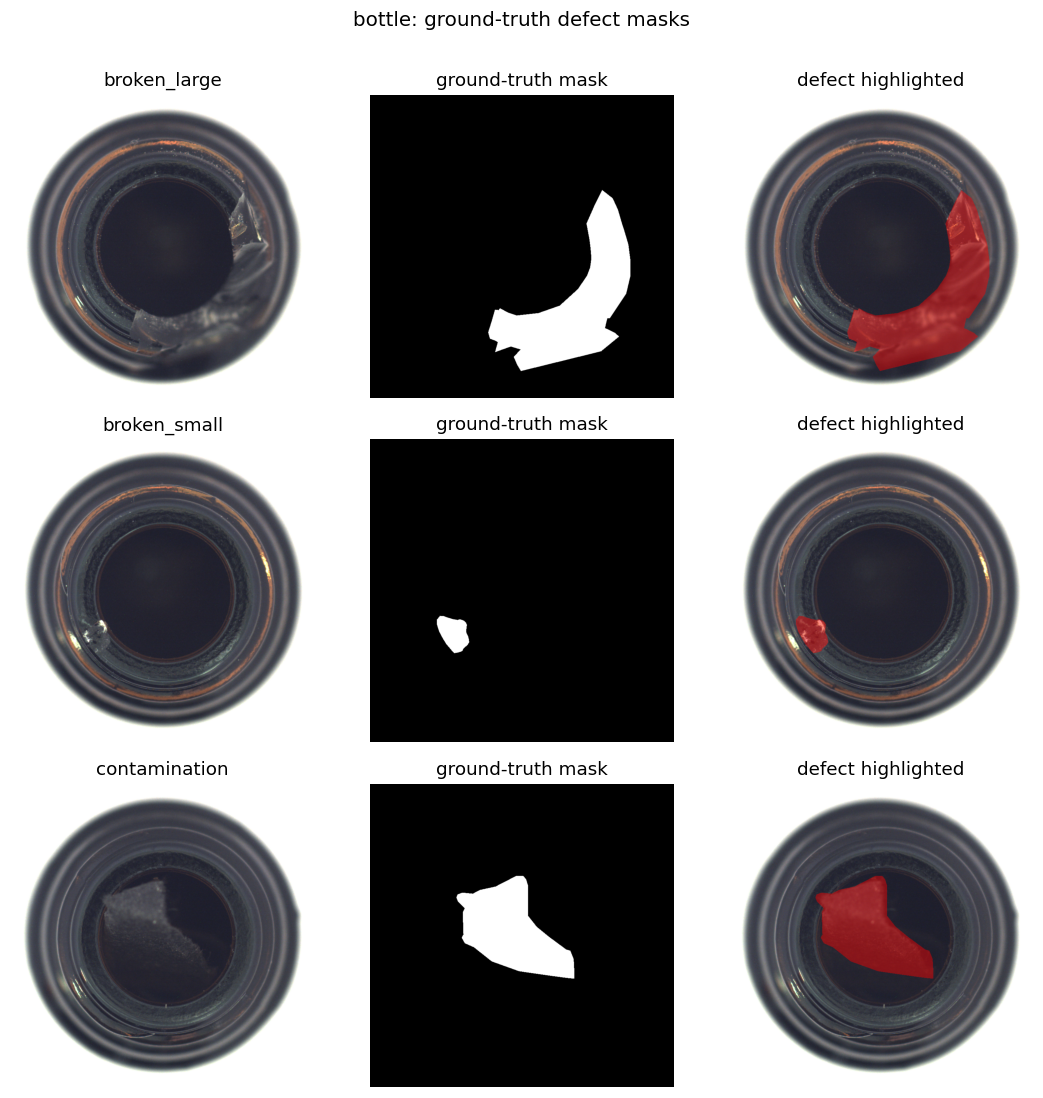

In [ ]:
# For each defect type, show: image | ground-truth mask | overlay
defect_only = [d for d in defect_dirs if d.name != 'good']
n_rows = len(defect_only)

fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3.3 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, ddir in enumerate(defect_only):
    img_path  = sorted(ddir.glob('*.png'))[0]
    # Mask path: same filename, in ground_truth/<defect>/, with _mask suffix
    mask_name = img_path.stem + '_mask.png'
    mask_path = cat_path / 'ground_truth' / ddir.name / mask_name

    img  = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path).convert('L'))

    # Overlay: tint defective pixels red
    overlay = img.copy()
    red_layer = np.zeros_like(img); red_layer[..., 0] = 255
    alpha = (mask > 0).astype(np.float32)[..., np.newaxis] * 0.45
    overlay = (img * (1 - alpha) + red_layer * alpha).astype(np.uint8)

    axes[row, 0].imshow(img);     axes[row, 0].set_title(f'{ddir.name}')
    axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title('ground-truth mask')
    axes[row, 2].imshow(overlay); axes[row, 2].set_title('defect highlighted')
    for ax in axes[row]:
        ax.axis('off')

fig.suptitle(f'{cat}: ground-truth defect masks', y=1.005, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / '03_ground_truth_masks.png')
plt.show()

**Key insight:** the white blob in the middle column is *exactly* what a perfect XAI method should highlight. Our job is to see how close Grad-CAM and LIME come to that.

## 4. How big are the defects?

What fraction of each image is actually defective? This matters because tiny defects are much harder to localize than huge ones — and our IoU evaluation needs to be calibrated against that.

/var/folders/h1/b9h12q3d24dg37j0czpckfqr0000gn/T/ipykernel_59068/278054167.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(fractions.keys()), patch_artist=True,


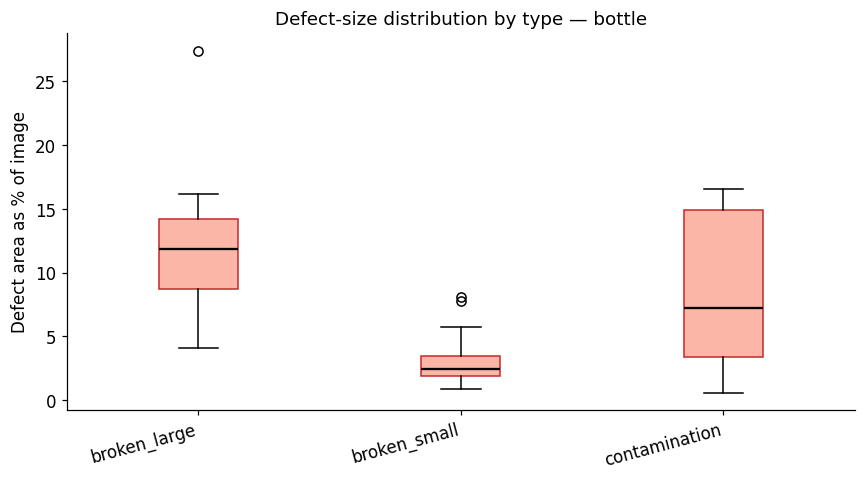


defect                   min    median     max
----------------------------------------------
broken_large           4.09%    11.87%  27.42%
broken_small           0.88%     2.44%   8.06%
contamination          0.58%     7.25%  16.53%


In [ ]:
# For every defective image, compute (defect_area / total_area) * 100
fractions = {}
for ddir in defect_only:
    mask_dir = cat_path / 'ground_truth' / ddir.name
    fracs = []
    for mask_path in sorted(mask_dir.glob('*.png')):
        mask = np.array(Image.open(mask_path).convert('L'))
        defect_frac = (mask > 0).sum() / mask.size * 100
        fracs.append(defect_frac)
    fractions[ddir.name] = fracs

# Box plot per defect type
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [fractions[d] for d in fractions]
bp = ax.boxplot(data, labels=list(fractions.keys()), patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5})
for patch in bp['boxes']:
    patch.set_facecolor('#FBB6A8')
    patch.set_edgecolor('#C62828')
ax.set_ylabel('Defect area as % of image')
ax.set_title(f'Defect-size distribution by type — {cat}')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIGURES / '04_defect_size_distribution.png')
plt.show()

# Summary stats
print(f'\n{"defect":<20}{"min":>8}{"median":>10}{"max":>8}')
print('-' * 46)
for d, fs in fractions.items():
    print(f'{d:<20}{min(fs):>7.2f}%{np.median(fs):>9.2f}%{max(fs):>7.2f}%')

## 5. Training transforms: before vs after

This shows what the model actually sees during training. We apply some random augmentation (flip, rotation, color jitter) so the model generalizes a bit better. The eval transform skips augmentation but still resizes and normalizes.

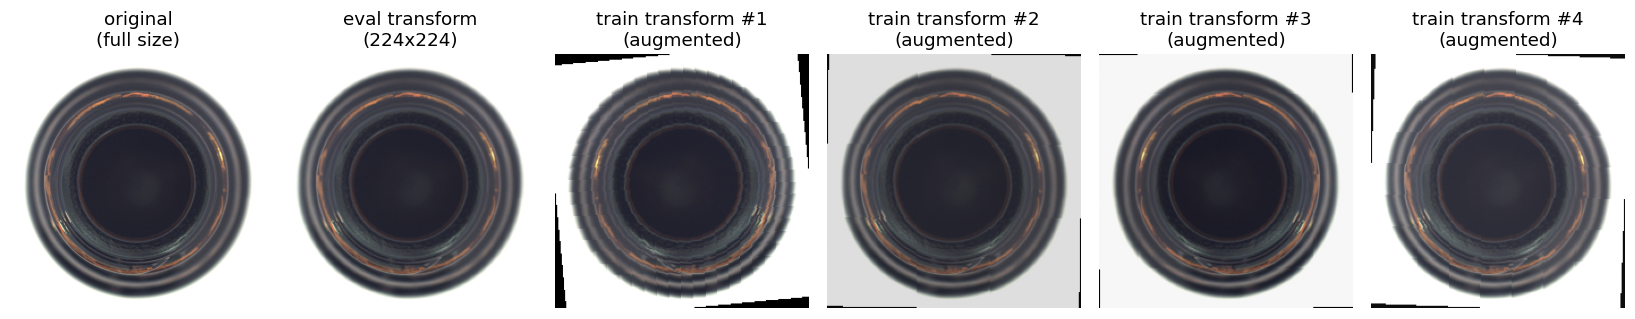

In [ ]:
# Pick one image and apply transforms multiple times to show variation
def denormalize(tensor):
    """Reverse the ImageNet normalization so the image looks right."""
    from config import IMAGENET_MEAN, IMAGENET_STD
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

img_path = sorted((cat_path / 'test/good').glob('*.png'))[0]
pil_img = Image.open(img_path).convert('RGB')

train_t = build_train_transform()
eval_t  = build_eval_transform()

# 1 original + 1 eval + 4 train variations
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

axes[0].imshow(pil_img); axes[0].set_title('original\n(full size)')
axes[1].imshow(denormalize(eval_t(pil_img))); axes[1].set_title(f'eval transform\n({IMAGE_SIZE}x{IMAGE_SIZE})')

torch.manual_seed(0)
for i in range(4):
    axes[2 + i].imshow(denormalize(train_t(pil_img)))
    axes[2 + i].set_title(f'train transform #{i+1}\n(augmented)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES / '05_transforms.png')
plt.show()

**What you should see:** the four "train transform" panels differ slightly from each other — flipped, rotated, brightness shifted. This variation makes the model less likely to memorize the training images.

## 6. Pipeline overview (for the slides)

A simple diagram showing the end-to-end flow. Drop this straight into the deck.

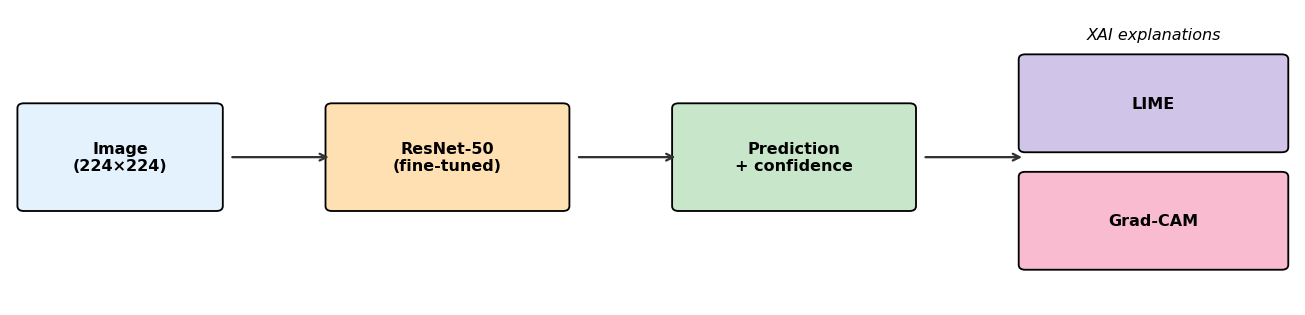

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 10); ax.set_ylim(0, 3)
ax.axis('off')

def box(x, y, w, h, label, color):
    from matplotlib.patches import FancyBboxPatch
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                       facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(p)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=10.5, fontweight='bold')

def arrow(x1, x2, y):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

box(0.1, 1.0, 1.5, 1.0, 'Image\n(224×224)',      '#E3F2FD')
arrow(1.7, 2.5, 1.5)
box(2.5, 1.0, 1.8, 1.0, 'ResNet-50\n(fine-tuned)','#FFE0B2')
arrow(4.4, 5.2, 1.5)
box(5.2, 1.0, 1.8, 1.0, 'Prediction\n+ confidence', '#C8E6C9')
arrow(7.1, 7.9, 1.5)
box(7.9, 0.4, 2.0, 0.9, 'Grad-CAM',    '#F8BBD0')
box(7.9, 1.6, 2.0, 0.9, 'LIME',        '#D1C4E9')
ax.text(8.9, 2.7, 'XAI explanations', ha='center', fontsize=10.5, style='italic')

plt.tight_layout()
plt.savefig(FIGURES / '06_pipeline.png')
plt.show()

## 7. After training: confusion matrix

The cells below only work after you have run `python src/train.py` and a `checkpoints/best_model.pt` exists. If it does not, they will skip with a friendly message.

In [ ]:
from config import CHECKPOINTS_DIR

CKPT = CHECKPOINTS_DIR / 'best_model.pt'
MODEL_READY = CKPT.exists()
print(f'Checkpoint exists: {MODEL_READY}')
if not MODEL_READY:
    print('Run `python src/train.py` first, then re-run this notebook from here.')

Checkpoint exists: True


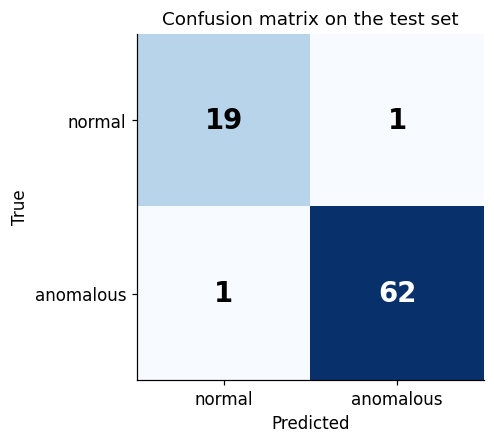

Accuracy : 0.976
Precision: 0.984
Recall   : 0.984
F1       : 0.984


In [ ]:
if MODEL_READY:
    from model import load_checkpoint
    from torch.utils.data import DataLoader
    import torch.nn.functional as F

    model = load_checkpoint(CKPT, DEVICE)
    test_ds = MVTecDataset(split='test', transform=build_eval_transform())
    loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            probs = F.softmax(model(x), dim=1).cpu().numpy()
            y_true.extend(y.tolist())
            y_pred.extend(probs.argmax(axis=1).tolist())
            y_score.extend(probs[:, 1].tolist())

    y_true = np.array(y_true); y_pred = np.array(y_pred); y_score = np.array(y_score)

    # Confusion matrix
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(4.5, 4.2))
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=18, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['normal', 'anomalous'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['normal', 'anomalous'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Confusion matrix on the test set')
    plt.tight_layout()
    plt.savefig(FIGURES / '07_confusion_matrix.png')
    plt.show()

    # Print metrics
    tp = cm[1, 1]; fp = cm[0, 1]; fn = cm[1, 0]; tn = cm[0, 0]
    acc       = (tp + tn) / cm.sum()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    print(f'Accuracy : {acc:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall   : {recall:.3f}')
    print(f'F1       : {f1:.3f}')
else:
    print('Skipped — no checkpoint yet.')

## 8. After training: Grad-CAM + LIME side by side

For each defective test image, show:
- the original
- the ground-truth defect mask
- Grad-CAM's heatmap
- LIME's region map

This is the money slide for the presentation.

  LIME on broken_large... (~30s)


  0%|          | 0/1000 [00:00<?, ?it/s]

  LIME on broken_small... (~30s)


  0%|          | 0/1000 [00:00<?, ?it/s]

  LIME on contamination... (~30s)


  0%|          | 0/1000 [00:00<?, ?it/s]

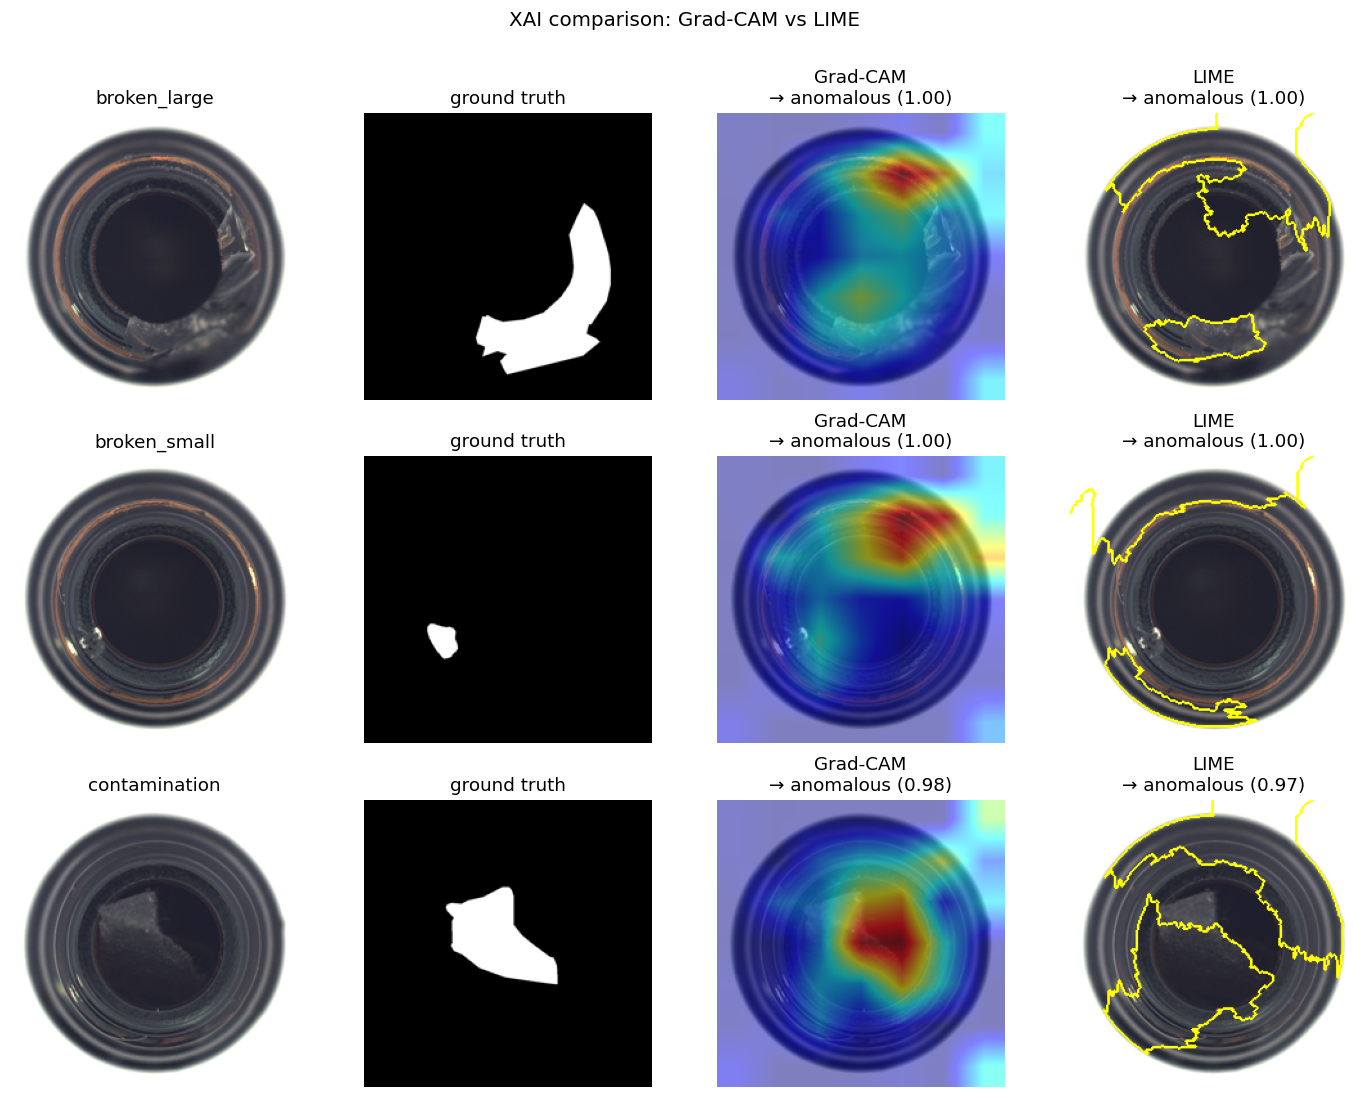

In [ ]:
if MODEL_READY:
    from gradcam_explain import compute_gradcam
    from lime_explain import compute_lime

    # Pick one image per defect type
    samples = []
    for ddir in defect_only:
        img_path = sorted(ddir.glob('*.png'))[0]
        mask_name = img_path.stem + '_mask.png'
        mask_path = cat_path / 'ground_truth' / ddir.name / mask_name
        samples.append((img_path, mask_path, ddir.name))

    n = len(samples)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, (img_path, mask_path, defect_name) in enumerate(samples):
        img = np.array(Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE)))
        mask = np.array(Image.open(mask_path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE)))

        _, gradcam_overlay, gc_label, gc_conf = compute_gradcam(img_path)
        print(f'  LIME on {defect_name}... (~30s)')
        _, lime_overlay, lm_label, lm_conf = compute_lime(img_path)

        axes[row, 0].imshow(img);            axes[row, 0].set_title(f'{defect_name}')
        axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title('ground truth')
        axes[row, 2].imshow(gradcam_overlay);   axes[row, 2].set_title(f'Grad-CAM\n→ {gc_label} ({gc_conf:.2f})')
        axes[row, 3].imshow(lime_overlay);      axes[row, 3].set_title(f'LIME\n→ {lm_label} ({lm_conf:.2f})')
        for ax in axes[row]:
            ax.axis('off')

    fig.suptitle('XAI comparison: Grad-CAM vs LIME', y=1.005, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / '08_xai_gallery.png')
    plt.show()
else:
    print('Skipped — no checkpoint yet.')

**Reading this plot:** the closer the colored region in columns 3 and 4 sits on top of the white blob in column 2, the better that XAI method localized the defect. This is the visual setup for the quantitative IoU evaluation we'll add next.

## Done

Every plot is saved under `figures/`. Pick the ones you want and drop them into the slides.

Next step: a notebook (or `src/evaluate.py`) that computes mean IoU between each XAI method's heatmap and the ground-truth masks across the whole test set — that gives us the quantitative numbers for the evaluation slide.

In [ ]:
# ============================================================================
# VERIFY: image ↔ mask pairing, alignment, and prediction accuracy
# ============================================================================
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # in a notebook
# sys.path.insert(0, str(Path('src').resolve()))     # in a .py file at project root

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

from config import DATA_DIR, CATEGORIES, IMAGE_SIZE, DEVICE, CHECKPOINTS_DIR
from model import load_checkpoint
from dataset import build_eval_transform

CATEGORY = CATEGORIES[0]
cat_path = DATA_DIR / CATEGORY

# ---------------------------------------------------------------------------
# Load model once
# ---------------------------------------------------------------------------
ckpt = CHECKPOINTS_DIR / 'best_model.pt'
assert ckpt.exists(), 'Train the model first: python src/train.py'
model = load_checkpoint(ckpt, DEVICE)
transform = build_eval_transform()
CLASS_NAMES = ['normal', 'anomalous']


def predict(image_path):
    """Returns (predicted_label, confidence)."""
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0]
    idx = int(probs.argmax().item())
    return CLASS_NAMES[idx], float(probs[idx].item())


def find_mask(image_path):
    """Find the matching ground-truth mask for an image, or None if normal."""
    defect_type = image_path.parent.name
    if defect_type == 'good':
        return None
    mask_path = cat_path / 'ground_truth' / defect_type / f'{image_path.stem}_mask.png'
    return mask_path if mask_path.exists() else None


# ---------------------------------------------------------------------------
# Pick N random test images, check everything
# ---------------------------------------------------------------------------
N = 6   # change to taste

all_test_images = sorted((cat_path / 'test').rglob('*.png'))
rng = np.random.default_rng(0)
sample = rng.choice(all_test_images, size=N, replace=False)

fig, axes = plt.subplots(N, 3, figsize=(11, 3.2 * N))
if N == 1:
    axes = axes[np.newaxis, :]

print(f'{"file":<35}{"true":<12}{"predicted":<14}{"conf":<7}{"mask?":<7}{"ok"}')
print('-' * 85)

correct = 0
for row, img_path in enumerate(sample):
    img_path = Path(img_path)
    true_label = 'anomalous' if img_path.parent.name != 'good' else 'normal'
    pred_label, conf = predict(img_path)
    mask_path = find_mask(img_path)

    is_correct = (true_label == pred_label)
    correct += is_correct
    flag = '✅' if is_correct else '❌'

    # Mask sanity: if anomalous, mask must exist; if normal, mask must NOT exist
    if true_label == 'anomalous':
        mask_ok = mask_path is not None and mask_path.exists()
    else:
        mask_ok = mask_path is None
    mask_flag = '✓' if mask_ok else '✗ MISSING'

    short_name = f'{img_path.parent.name}/{img_path.name}'
    print(f'{short_name:<35}{true_label:<12}{pred_label:<14}{conf:.3f}  {mask_flag:<7}{flag}')

    # --- Plot ---
    img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    img_np = np.array(img)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'image\n{img_path.parent.name}/{img_path.name}', fontsize=9)
    axes[row, 0].axis('off')

    if mask_path is not None and mask_path.exists():
        mask = np.array(Image.open(mask_path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE)))
        axes[row, 1].imshow(mask, cmap='gray')
        axes[row, 1].set_title(f'mask: {mask_path.name}', fontsize=9)

        # Overlay to verify pixel alignment
        red = np.zeros_like(img_np); red[..., 0] = 255
        alpha = (mask > 127).astype(np.float32)[..., np.newaxis] * 0.5
        overlay = (img_np * (1 - alpha) + red * alpha).astype(np.uint8)
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'overlay\n(red=defect)', fontsize=9)
    else:
        axes[row, 1].text(0.5, 0.5, 'no mask\n(normal image)',
                          ha='center', va='center', transform=axes[row, 1].transAxes,
                          fontsize=11, color='gray')
        axes[row, 2].text(0.5, 0.5, 'n/a',
                          ha='center', va='center', transform=axes[row, 2].transAxes,
                          fontsize=11, color='gray')

    # Color the title border by correctness
    title_color = '#2E7D32' if is_correct else '#C62828'
    axes[row, 0].set_title(
        f'image\ntrue={true_label} | pred={pred_label} ({conf:.2f})',
        fontsize=9, color=title_color, fontweight='bold'
    )

    for ax in axes[row]:
        ax.axis('off')

print('-' * 85)
print(f'Correct: {correct}/{N}  ({100*correct/N:.1f}%)')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / '09_verification.png', dpi=180, bbox_inches='tight')
plt.show()